<a href="https://colab.research.google.com/github/Dcarlos-02/DATA201__SP26/blob/main/Week5_assignment_resampling_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week5 assignment**

## Loading data and libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
#print the number of observation
print(f'The number of observation is: {df.shape[0]}')

The number of observation is: 150


In [5]:
#printing the column names

print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [ ]:
#printing total observation for each species
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# **PART1--Bootstrap resampling**

### Computing basic stats for petal_length

In [ ]:
#average length

avg_petal_length = np.mean(df['sepal_length'])

print(f"The average sepal length is: {avg_petal_length}")


#median length

median_length = np.median(df['sepal_length'])

print(f"The median sepal length is: {median_length}")


#petal lenght standard deviation

stdv_petal_length = np.std(df['sepal_length'])

print(f"The standard deviation is: {stdv_petal_length}")


The average sepal length is: 5.843333333333334
The median sepal length is: 5.8
The standard deviation is: 0.8253012917851409


## Bootstrapping the mean



In [ ]:

bootstrap_means = []

iteration = 5000

for i in range(iteration):
  sample = df['sepal_length'].sample(n=150, replace=True)
  bootstrap_means.append(np.mean(sample))


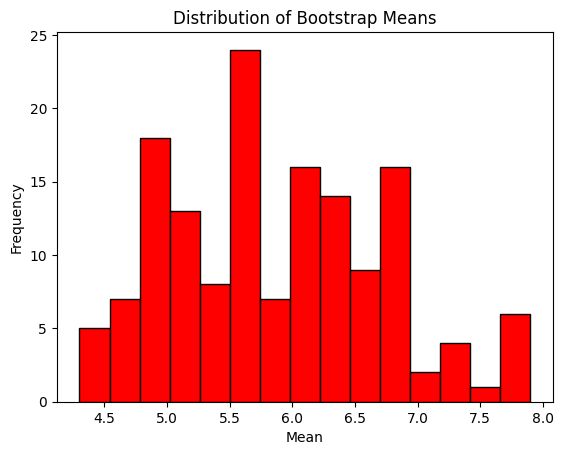

In [ ]:
plt.hist(sample, bins=15, edgecolor='black')
plt.title('Distribution of Bootstrap Means')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.show()

## Confidence interval



In [ ]:

lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

boots_mean = np.mean(bootstrap_means)

print(f'The lower bound is: {lower_bound:.3f}')
print(f'The upper bound is: {upper_bound:.3f}')
print(f'The bootstrap mean is: {boots_mean:.3f}')

The lower bound is: 5.714
The upper bound is: 5.977
The bootstrap mean is: 5.843


It is mathematically necessary to sample with replacement because if we do otherwise, every sample would be like a permuation of the data. Sampling with replacement gives opportunity for more variation where some elements might be drawn more than one time.

# **Part2---Jacknife resampling**

In [ ]:
jacknife_means = []

n = len(df['sepal_length'])

for i in range(n):
  sample2 = df['sepal_length'].drop(i)
  jacknife_means.append(np.mean(sample2))

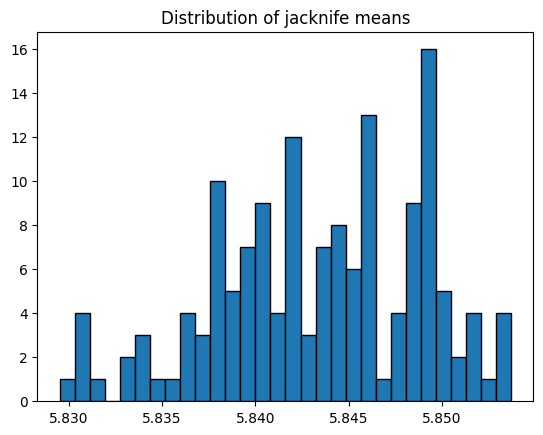

In [ ]:
plt.hist(jacknife_means, bins=30, edgecolor='black')
plt.title('Distribution of jacknife means')
plt.show()

If the dataset contains n observations, exactly n jacknife sample are created. For instance, i this specific case, 150 samples were created.

# **PART3--Permutation test**

### **Difference in means**

In [ ]:
versicolor = df[df['species'] == 'versicolor']['sepal_length']
virginica = df[df['species'] == 'virginica']['sepal_length']

In [ ]:
diff_mean = np.mean(versicolor)-np.mean(virginica)
print(f'The difference in means between the two species is: {diff_mean:.3f}')

The difference in means between the two species is: -0.652


### **Permutation simulation**

In [ ]:
combined = np.concatenate([versicolor, virginica])
n_versi = len(versicolor)
perm_diff = []

In [ ]:
for i in range(1000):
  shuffled = np.random.permutation(combined)

  new_versicolor = shuffled[:n_versi]
  new_virginica = shuffled[n_versi:]
  perm_diff.append(np.mean(new_versicolor)-np.mean(new_virginica))

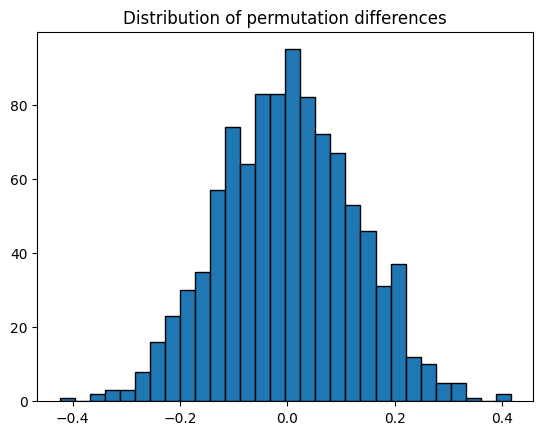

In [ ]:
plt.hist(perm_diff, bins=30, edgecolor='black')
plt.title('Distribution of permutation differences')
plt.show()

### P-value

In [ ]:
p_val = np.sum(np.array(perm_diff)<=diff_mean)/1000

print(f'Observed difference: {diff_mean:.3f}')
print(f'p-value: {p_val:.9f}')

Observed difference: -0.652
p-value: 0.000000000


**Null Hypothesis ($H_0$):** There is no significant difference between the mean sepal length of Versicolor and Virginica flowers.

**What the distribution represents:** It represents the range of differences we would expect to see if the species labels were completely meaningless.

**The Verdict:** With a p-value typically resulting in $< 0.001$ (below $\alpha = 0.05$), we reject the null hypothesis. The difference in sepal length between these two species is statistically significant.